In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
import numpy as np

# انتخاب عدد موردنظر برای تجزیه و یک عدد نسبت به آن اول
public_key = 15
coprime = 7
#coprime = 11

# ساخت دنباله تناوبی a^x mod N
vector = []
for i in range(8):
    vector.append((coprime ** i) % public_key)
norm = np.linalg.norm(vector)                      # نرمال‌سازی بردار حالت
statevector = vector / norm

print('vector:')
print(vector)
print('statevector:')
print(statevector)

vector:
[1, 7, 4, 13, 1, 7, 4, 13]
statevector:
[0.04612656 0.32288592 0.18450624 0.59964529 0.04612656 0.32288592
 0.18450624 0.59964529]


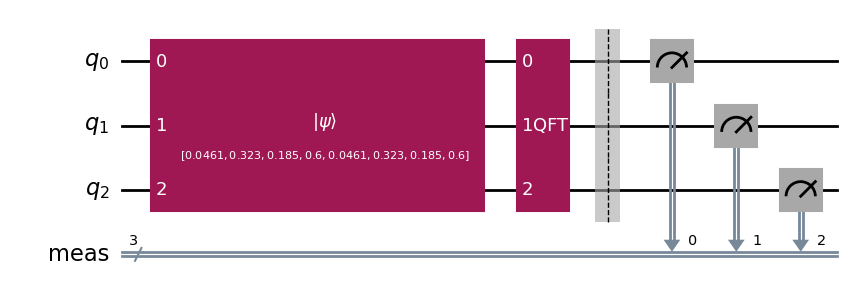

In [ ]:
#اعمال تبدیل فوریه کوانتومی برای استخراج تناوب
circ = QuantumCircuit(3)
circ.initialize(statevector)
circ.append(QFT(3), [0, 1, 2])
circ.measure_all()
display(circ.draw('mpl'))

c8339a35-f533-4df4-9fef-7f0f6f6754e1
{'000': 662, '100': 247, '010': 50, '110': 41}


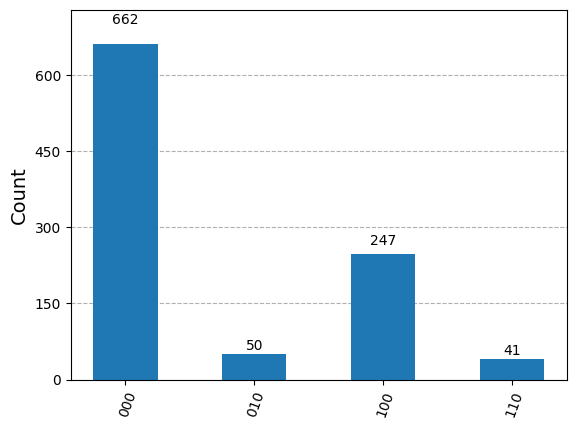

In [ ]:
# شبیه‌سازی مدار و به‌دست‌آوردن نتایج اندازه‌گیری
device = AerSimulator()

circ_transpiled = transpile(circ, device)

job = device.run(circ_transpiled, shots=1000)

print(job.job_id())

result = job.result()

counts = result.get_counts(circ_transpiled)

print(counts)

display(plot_histogram(counts))

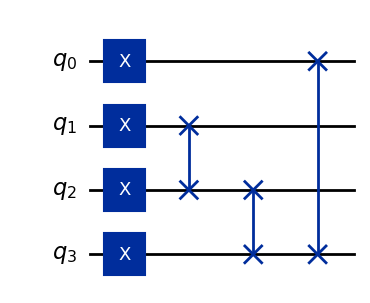

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

# ساخت مدار ضرب پیمانه‌ای 7 به پیمانه 15
_7k_mod15 = QuantumCircuit(4)
_7k_mod15.x([0, 1, 2, 3])
_7k_mod15.swap(1, 2)
_7k_mod15.swap(2, 3)
_7k_mod15.swap(0, 3)
display(_7k_mod15.draw('mpl'))

In [ ]:
# ساخت مدار ضرب پیمانه‌ای 7 به پیمانه 15
def _7EPXn_mod15(n):
    circ = QuantumCircuit(4)
    for k in range(n):
        circ = circ.compose(_7k_mod15, qubits=[0, 1, 2, 3])

    gate = circ.to_gate(label='(7^'+ str(n) + ') mod15')
    return gate.control(1, ctrl_state='1')

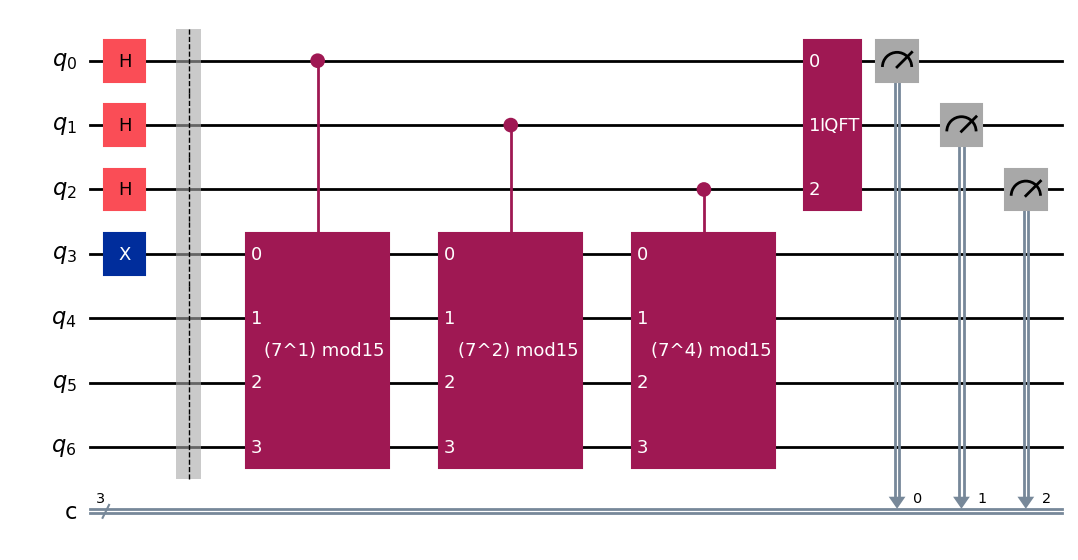

In [ ]:
from qiskit.circuit.library import QFT

# ساخت مدار اصلی الگوریتم شور
circ = QuantumCircuit(7, 3)
circ.h([0, 1, 2])           # ایجاد برهم‌نهی یکنواخت در ثبات شمارش
circ.x(3)                   # آماده‌سازی ثبات دوم در حالت پایه
circ.barrier()

# اعمال توان‌های کنترل‌شده تابع پیمانه‌ای
circ.append(_7EPXn_mod15(1), [0, 3, 4, 5, 6])
circ.append(_7EPXn_mod15(2), [1, 3, 4, 5, 6])
circ.append(_7EPXn_mod15(4), [2, 3, 4, 5, 6])

# اعمال تبدیل فوریه کوانتومی معکوس
circ.append(QFT(3).inverse(), [0, 1, 2])

# اندازه‌گیری ثبات شمارش
circ.measure([0, 1, 2], [0, 1, 2])

display(circ.draw('mpl'))

In [5]:
from qiskit import transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator()

# شکستن گیت‌های مرکب به گیت‌های قابل اجرای Aer
circ_transpiled = transpile(circ, simulator)

# اجرای مدار
job = simulator.run(circ_transpiled, shots=1024)

# گرفتن نتیجه
result = job.result()
counts = result.get_counts()

print("Measurement results:")
print(counts)

Measurement results:
{'010': 264, '100': 245, '000': 274, '110': 241}
